# AIDL A02: Neural Networks and Deep Learning PROJECT

## Student: Zelios Andreas mscaids-0142

## Custom CNN networks

> Words for the dataset can be found [here](https://www.keng.gr/%CE%BB%CE%B5%CE%BE%CE%B9%CE%BA%CF%8C-%CE%B5%CE%BB%CE%BB%CE%B7%CE%BD%CE%B9%CE%BA%CE%AE%CF%82-%CE%BD%CE%BF%CE%B7%CE%BC%CE%B1%CF%84%CE%B9%CE%BA%CE%AE%CF%82-%CE%B3%CE%BB%CF%8E%CF%83%CF%83%CE%B1%CF%82/)  

In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras import utils
from sklearn.model_selection import train_test_split
import os
import cv2
import numpy as np
%matplotlib inline
from google.colab import drive

In [2]:
# load data
drive.mount('/content/drive')

def load_data(dataset_dir):
    images = []
    labels = []
    size = 224,224
    index = -1
    for folder in sorted(os.listdir(dataset_dir)):
        index +=1
        for image in os.listdir(dataset_dir + "/" + folder):
            temp_img = cv2.imread(dataset_dir + '/' + folder + '/' + image)
            temp_img = cv2.resize(temp_img, size)
            images.append(temp_img)
            labels.append(index)

    images = np.array(images)
    images = images.astype('float32')/255.0
    labels = utils.to_categorical(labels)

    x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size = 0.3, random_state = 1)

    print('Loaded', len(x_train),'images for training,','Train data shape =', x_train.shape)
    print('Loaded', len(x_test),'images for testing','Test data shape =', x_test.shape)
    return x_train, x_test, y_train, y_test

dataset_dir = '/content/drive/MyDrive/AIDL02/PROJECT/DATA'

# initial test and training
x_train, x_test, y_train, y_test = load_data(dataset_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 247 images for training, Train data shape = (247, 224, 224, 3)
Loaded 106 images for testing Test data shape = (106, 224, 224, 3)


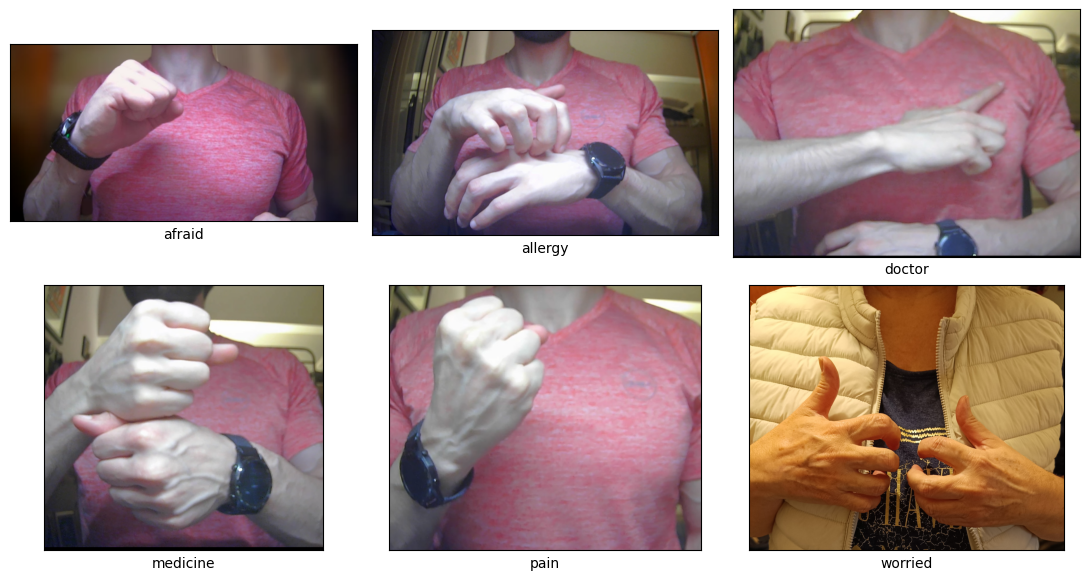

In [3]:
classes = ['afraid', 'allergy', 'doctor', 'medicine', 'pain', 'worried']
plt.figure(figsize=(11, 6))

for i in range(0, 6):
    plt.subplot(2, 3, i+1)
    plt.xticks([])
    plt.yticks([])

    folder_path = dataset_dir + "/" + classes[i]
    first_image_name = sorted(os.listdir(folder_path))[0]
    path = folder_path + "/" + first_image_name

    img = plt.imread(path)
    plt.imshow(img)
    plt.xlabel(classes[i])

plt.tight_layout()
plt.show()

In [4]:
# we now split the training to validation/testing
x_train_n, x_val, y_train_n, y_val = train_test_split(x_train, y_train, test_size = 0.3, random_state = 1)


#1. Custom CNN networks


### Network 1

- Added small batch size, due to small dataset
- Dropout after the layer with parameters (convolutional) to be more generalized and avoid overfitting
- stride is higher in maxpool because we want to drop weights, where in convolutional we want to extract features
- Steadily increase filter size, to first get more general features and then extract more details
- Small size Network because we have small dataset

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
seed = 2
tf.random.set_seed(seed)
np.random.seed(seed)

model = Sequential()

# 224x224 x 3 channels, so 150.528 features each image
model.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(224,224,3)))
model.add(MaxPool2D((2,2), strides=2))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model.add(MaxPool2D((2,2), strides=2))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.2))
# we have multiple classes, so sigmoid cannot be used
model.add(Dense(len(classes), activation="softmax"))

# power of two to utilize as much memory due to how computers work
# and small, because the dataset is not very large
batch_size = 64
epochs = 200
model_path_one = f'best_model1.h5'
save_model = ModelCheckpoint(model_path_one, save_best_only=True, monitor='val_loss', mode='min', verbose=2)
early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
# shuffle to true to check more data, maybe the model does not see ever let's say doctor
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_1 = model.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle=True, validation_data=(x_val, y_val), callbacks=[save_model, early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2475 - loss: 19.5343   
Epoch 1: val_loss improved from None to 16.51019, saving model to best_model1.h5



Epoch 1: finished saving model to best_model1.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 11s/step - accuracy: 0.2267 - loss: 29.3488 - val_accuracy: 0.1733 - val_loss: 16.5102
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.2188 - loss: 21.5980
Epoch 2: val_loss improved from 16.51019 to 4.46228, saving model to best_model1.h5



Epoch 2: finished saving model to best_model1.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 13s/step - accuracy: 0.2267 - loss: 19.0956 - val_accuracy: 0.1067 - val_loss: 4.4623
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2571 - loss: 6.9171 
Epoch 3: val_loss improved from 4.46228 to 1.94279, saving model to best_model1.h5



Epoch 3: finished saving model to best_model1.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 7s/step - accuracy: 0.2558 - loss: 5.6754 - val_accuracy: 0.2000 - val_loss: 1.9428
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.2207 - loss: 2.6266
Epoch 4: val_loss improved from 1.94279 to 1.77949, saving model to best_model1.h5


...


Epoch 121: finished saving model to best_model1.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - accuracy: 1.0000 - loss: 1.1460e-04 - val_accuracy: 0.9733 - val_loss: 0.0728
Epoch 122/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 1.0000 - loss: 5.8302e-05
Epoch 122: val_loss improved from 0.07282 to 0.07181, saving model to best_model1.h5



Epoch 122: finished saving model to best_model1.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 1.0000 - loss: 5.8114e-05 - val_accuracy: 0.9733 - val_loss: 0.0718
Epoch 123/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - loss: 1.5529e-04 
Epoch 123: val_loss improved from 0.07181 to 0.06542, saving model to best_model1.h5



Epoch 123: finished saving model to best_model1.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - accuracy: 1.0000 - loss: 2.4658e-04 - val_accuracy: 0.9733 - val_loss: 0.0654
Epoch 124/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 1.0000 - loss: 1.9773e-04
Epoch 124: val_loss improved from 0.06542 to 0.05751, saving model to best_model1.h5



Epoch 124: finished saving model to best_model1.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 16s/step - accuracy: 1.0000 - loss: 2.0704e-04 - val_accuracy: 0.9867 - val_loss: 0.0575
Epoch 125/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 1.0000 - loss: 2.6448e-04
Epoch 125: val_loss improved from 0.05751 to 0.05608, saving model to best_model1.h5



Epoch 125: finished saving model to best_model1.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 1.0000 - loss: 2.1075e-04 - val_accuracy: 0.9867 - val_loss: 0.0561
Epoch 126/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 1.0000 - loss: 5.3728e-05
Epoch 126: val_loss did not improve from 0.05608
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 1.0000 - loss: 6.6114e-05 - val_accuracy: 0.9867 - val_loss: 0.0568
Epoch 127/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 6.0313e-05 
Epoch 127: val_loss did not improve from 0.05608
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 1.0000 - loss: 6.6548e-05 - val_accuracy: 0.9867 - val_loss: 0.0581
Epoch 128/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 6.5899e-05 
Epoch 128: val_loss did not improve from 0.05608
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 1.0000 - loss: 6.9137e-05 - val_accuracy: 0.9867 - val_loss: 0.0592
Epoch 129/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - 

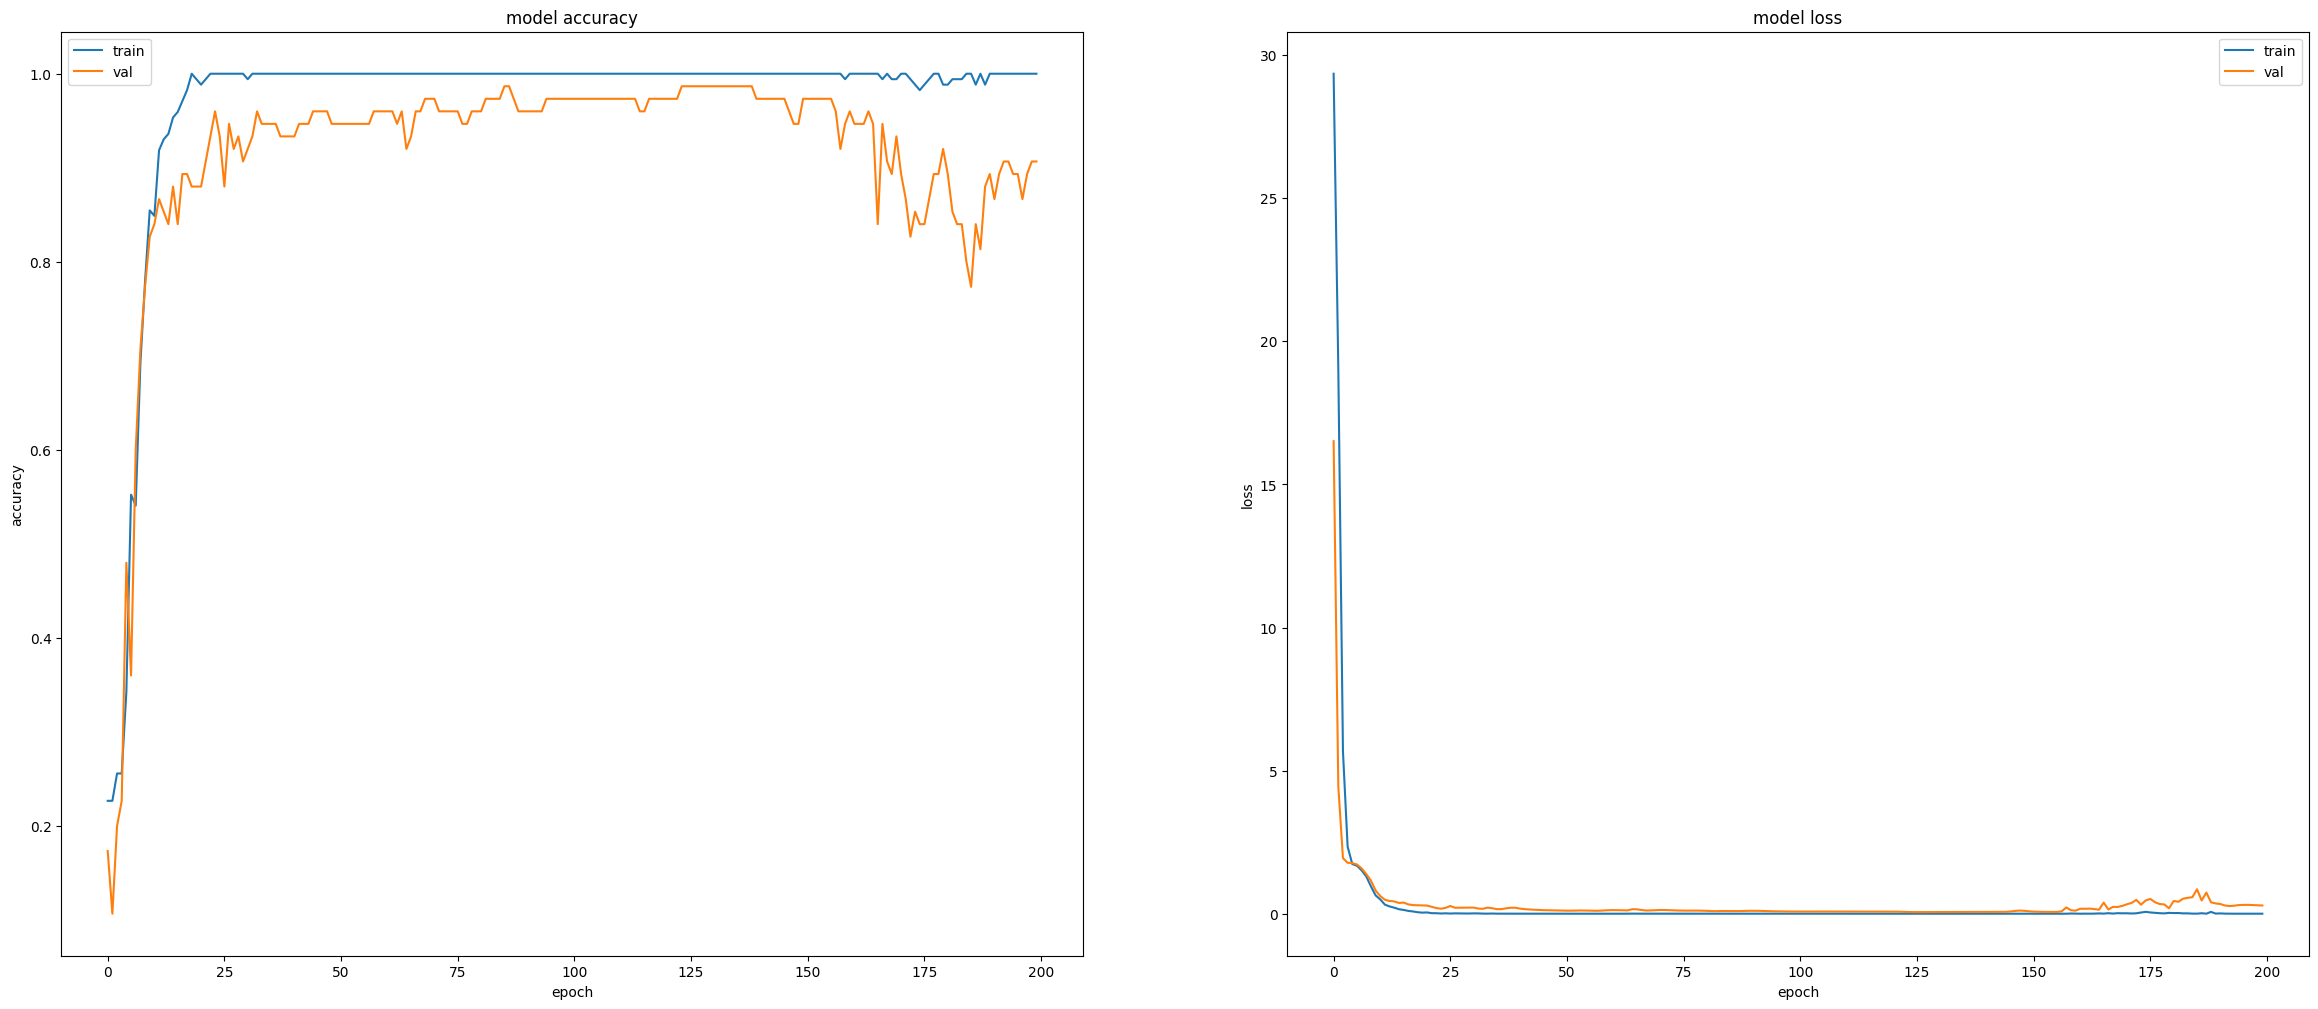

In [ ]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

In [13]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step
Accuracy: 0.8962264150943396
Recal: 0.9015254435107375
F1: 0.8996368992223185
Precision: 0.9028128507295174


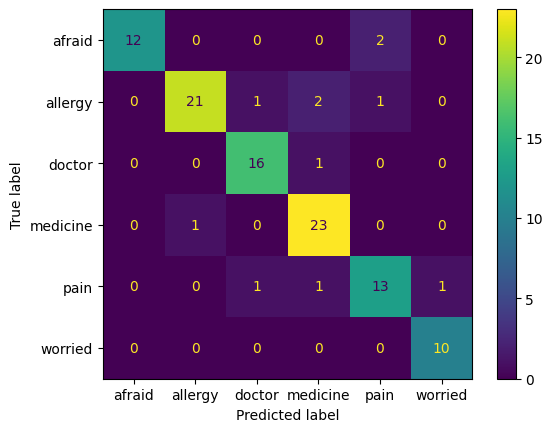

In [ ]:
history_1.model.load_weights('best_model1.h5')

predictions=history_1.model.predict(x_test)

y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()

## Network 2

Differences are:
- **BatchNormalization** because we want to avoid *expoding gradients*
- **Different optimizer** (rmsprop) just to see it working without stochastic gradient decent as adam uses combination of both
- **Higher epocs**, with combination of *higher patients* to actually use them
- Bigger Network (VGG like)

In [5]:
from tensorflow.keras.layers import BatchNormalization

In [ ]:
model_two = Sequential()

model_two.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(224,224,3)))
model_two.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(MaxPool2D((2,2), strides=2))
model_two.add(Dropout(0.2))

model_two.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(MaxPool2D((2,2), strides=2))
model_two.add(Dropout(0.2))

model_two.add(Conv2D(128, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(Conv2D(128, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(MaxPool2D((2,2), strides=2))
model_two.add(Dropout(0.2))

model_two.add(Flatten()) # maybe use GlobalAveragePooling2D()
model_two.add(Dense(units=512, activation='relu'))
model_two.add(Dropout(0.2))

model_two.add(Dense(len(classes), activation="softmax"))

batch_size = 64
epochs = 300
model_path_two = f'best_model2.h5'
save_model = ModelCheckpoint(model_path_two, save_best_only=True, monitor='val_loss', mode='min', verbose=2)
early_stop = EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True)

model_two.compile(loss="categorical_crossentropy", optimizer='rmsprop', metrics=["accuracy"])
history_2 = model_two.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle=True, validation_data=(x_val, y_val), callbacks=[save_model, early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.1272 - loss: 5.4199  
Epoch 1: val_loss improved from None to 1.79288, saving model to best_model2.h5



Epoch 1: finished saving model to best_model2.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 105s 35s/step - accuracy: 0.1395 - loss: 6.4492 - val_accuracy: 0.2000 - val_loss: 1.7929
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.1910 - loss: 1.7933
Epoch 2: val_loss improved from 1.79288 to 1.78999, saving model to best_model2.h5



Epoch 2: finished saving model to best_model2.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 20s/step - accuracy: 0.1744 - loss: 1.7929 - val_accuracy: 0.2000 - val_loss: 1.7900
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.2208 - loss: 1.7918
Epoch 3: val_loss did not improve from 1.78999
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 0.2093 - loss: 1.7954 - val_accuracy: 0.1733 - val_loss: 1.7900
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.2019 - loss: 1.7823
Epoch 4: val_loss improved from 1.78999 to 1.77726, saving model to best_model2.h5



Epoch 4: finished saving model to best_model2.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.2384 - loss: 1.7818 - val_accuracy: 0.2933 - val_loss: 1.7773
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.2429 - loss: 1.7704
Epoch 5: val_loss did not improve from 1.77726
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 0.2442 - loss: 1.7822 - val_accuracy: 0.1733 - val_loss: 1.7880
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.2506 - loss: 1.7715
Epoch 6: val_loss improved from 1.77726 to 1.73866, saving model to best_model2.h5


...


Epoch 25: finished saving model to best_model2.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.8663 - loss: 0.3731 - val_accuracy: 0.8533 - val_loss: 0.4434
Epoch 26/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8597 - loss: 0.3053
Epoch 26: val_loss did not improve from 0.44342
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step - accuracy: 0.8605 - loss: 0.2977 - val_accuracy: 0.8133 - val_loss: 0.4912
Epoch 27/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8806 - loss: 0.3799
Epoch 27: val_loss did not improve from 0.44342
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 337ms/step - accuracy: 0.8605 - loss: 0.4580 - val_accuracy: 0.7867 - val_loss: 1.6032
Epoch 28/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.5515 - loss: 1.5254
Epoch 28: val_loss did not improve from 0.44342
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step - accuracy: 0.4593 - loss: 1.6366 - val_accuracy: 0.8000 - val_loss: 0.5125
Epoch 29/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8324 - loss: 0.4161
Epoc


Epoch 37: finished saving model to best_model2.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.8081 - loss: 0.5484 - val_accuracy: 0.8800 - val_loss: 0.3333
Epoch 38/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.8675 - loss: 0.3282
Epoch 38: val_loss improved from 0.33330 to 0.31883, saving model to best_model2.h5



Epoch 38: finished saving model to best_model2.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8837 - loss: 0.2995 - val_accuracy: 0.8933 - val_loss: 0.3188
Epoch 39/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9253 - loss: 0.2296
Epoch 39: val_loss improved from 0.31883 to 0.31447, saving model to best_model2.h5



Epoch 39: finished saving model to best_model2.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.9244 - loss: 0.2226 - val_accuracy: 0.9067 - val_loss: 0.3145
Epoch 40/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9526 - loss: 0.1597
Epoch 40: val_loss did not improve from 0.31447
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.9593 - loss: 0.1409 - val_accuracy: 0.8667 - val_loss: 0.5428
Epoch 41/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9019 - loss: 0.2759
Epoch 41: val_loss did not improve from 0.31447
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.9244 - loss: 0.2413 - val_accuracy: 0.9467 - val_loss: 0.3373
Epoch 42/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9552 - loss: 0.1013
Epoch 42: val_loss did not improve from 0.31447
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step - accuracy: 0.9593 - loss: 0.0948 - val_accuracy: 0.9200 - val_loss: 0.3803
Epoch 43/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9383 - loss: 0.1405
Epo


Epoch 138: finished saving model to best_model2.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.9467 - val_loss: 0.3120
Epoch 139/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 1.0000 - loss: 0.0024
Epoch 139: val_loss did not improve from 0.31202
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9333 - val_loss: 0.3241
Epoch 140/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 140: val_loss did not improve from 0.31202
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9333 - val_loss: 0.3542
Epoch 141/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 1.0000 - loss: 0.0013
Epoch 141: val_loss did not improve from 0.31202
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step - accuracy: 1.0000 - loss: 9.9402e-04 - val_accuracy: 0.9200 - val_loss: 0.3461
Epoch 142/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 1.0000 - loss:

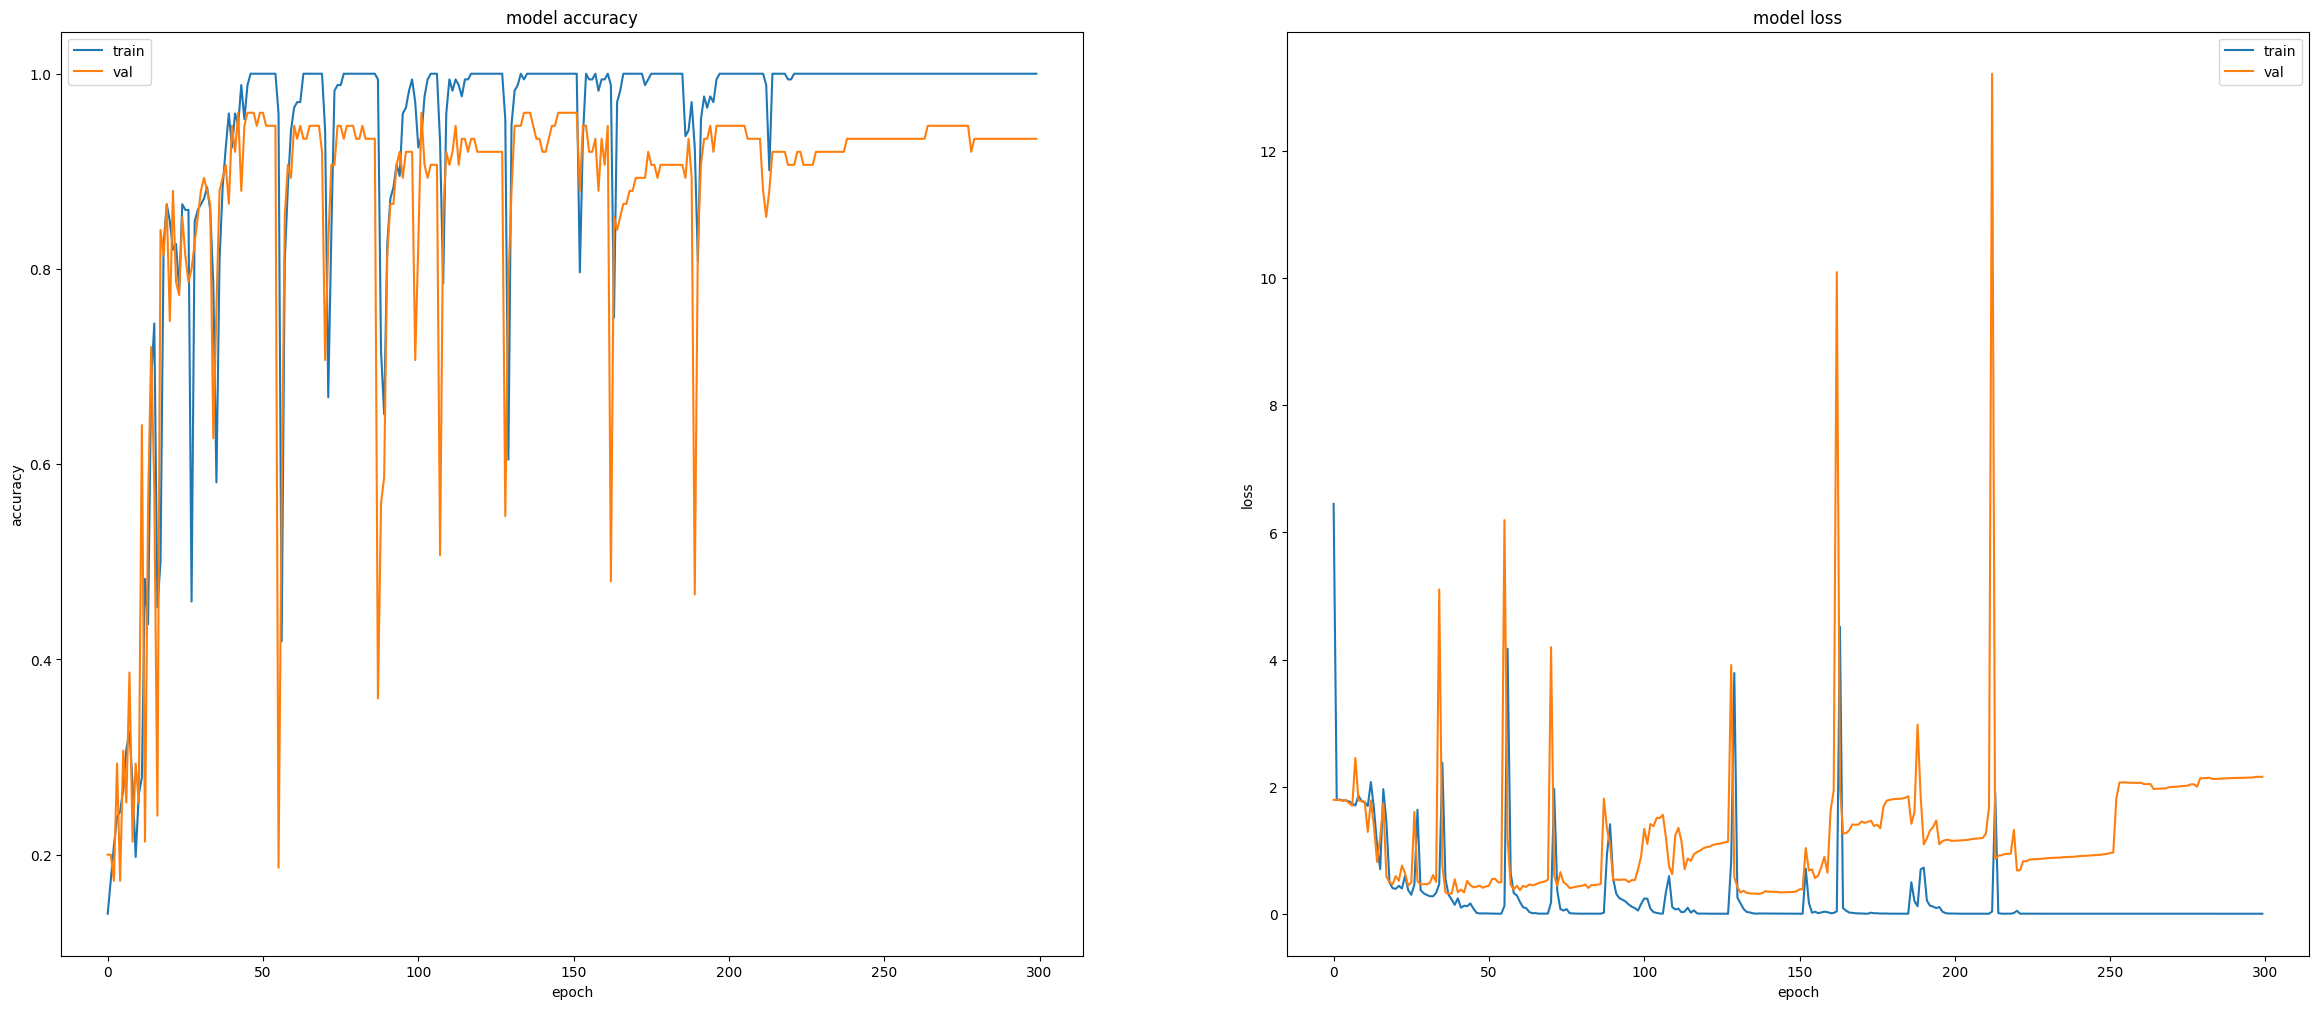

In [ ]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 510ms/step
Accuracy: 0.9245283018867925
Recal: 0.9231746031746031
F1: 0.9229308390022677
Precision: 0.9285806785806785


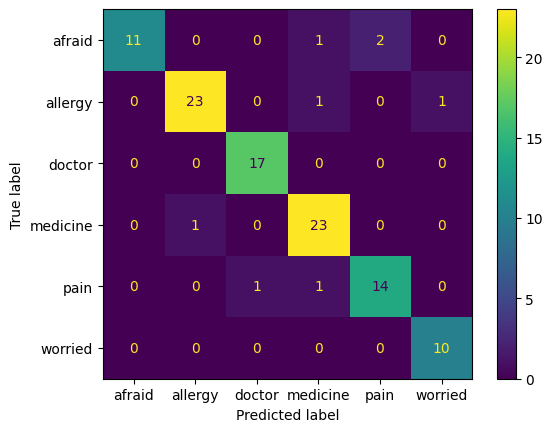

In [ ]:
history_2.model.load_weights('best_model2.h5')

predictions2=history_2.model.predict(x_test)

y_pred_classes = np.argmax(predictions2, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm2 = confusion_matrix(y_true_classes, y_pred_classes)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=classes)
disp2.plot()

## Network 3

- smaller patience to avoid overfitting
- added back Adam as optimizer
- used GlobalAveragePooling2D instead of Flattening
- one more convolutional layer with batch normalization, maxpool and dropout with slightly higher value to avoid overfitting also

In [6]:
from tensorflow.keras.layers import GlobalAveragePooling2D

In [ ]:
model_three = Sequential()

model_three.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(224,224,3)))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.2))

model_three.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.2))

model_three.add(Conv2D(128, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.3))

model_three.add(Conv2D(128, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.3))

model_three.add(GlobalAveragePooling2D())

model_three.add(Dense(units=256, activation='relu'))
model_three.add(Dropout(0.2))
model_three.add(Dense(len(classes), activation="softmax"))

batch_size = 64
epochs = 300
model_path_three = f'best_model3.h5'
save_model = ModelCheckpoint(model_path_three, save_best_only=True, monitor='val_loss', mode='min', verbose=2)
early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

model_three.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_3 = model_three.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle=True, validation_data=(x_val, y_val), callbacks=[save_model, early_stop])

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1779 - loss: 1.9476   
Epoch 1: val_loss improved from None to 1.78932, saving model to best_model3.h5



Epoch 1: finished saving model to best_model3.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 8s/step - accuracy: 0.1744 - loss: 1.9491 - val_accuracy: 0.1867 - val_loss: 1.7893
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3533 - loss: 1.7267
Epoch 2: val_loss improved from 1.78932 to 1.78733, saving model to best_model3.h5



Epoch 2: finished saving model to best_model3.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.3256 - loss: 1.7527 - val_accuracy: 0.2000 - val_loss: 1.7873
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3072 - loss: 1.6554
Epoch 3: val_loss improved from 1.78733 to 1.78521, saving model to best_model3.h5



Epoch 3: finished saving model to best_model3.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.2965 - loss: 1.6634 - val_accuracy: 0.2000 - val_loss: 1.7852
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3591 - loss: 1.5939
Epoch 4: val_loss improved from 1.78521 to 1.78357, saving model to best_model3.h5



Epoch 4: finished saving model to best_model3.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.3430 - loss: 1.5945 - val_accuracy: 0.2000 - val_loss: 1.7836
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4286 - loss: 1.4959
Epoch 5: val_loss did not improve from 1.78357
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.4186 - loss: 1.5014 - val_accuracy: 0.2000 - val_loss: 1.7865
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.4512 - loss: 1.4552
Epoch 6: val_loss did not improve from 1.78357
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.4709 - loss: 1.4394 - val_accuracy: 0.2000 - val_loss: 1.7918
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.4760 - loss: 1.3923
Epoch 7: val_loss did not improve from 1.78357
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.4593 - loss: 1.3843 - val_accuracy: 0.2000 - val_loss: 1.8010
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.4585 - loss: 1.3414
Epoch 8: 

In [ ]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

In [ ]:
history_3.model.load_weights('best_model3.h5')

predictions3=history_3.model.predict(x_test)

y_pred_classes = np.argmax(predictions3, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm3 = confusion_matrix(y_true_classes, y_pred_classes)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=classes)
disp3.plot()

#2. Transfer learning

## 1. VGG16

In [7]:
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.optimizers import Adam

In [ ]:
model_vgg = Sequential()
model_vgg.add(VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3)))
model_vgg.add(Flatten())
model_vgg.add(Dense(512, activation='relu'))
model_vgg.add(Dense(len(classes), activation='softmax'))

learning_rate = 0.0001
batch_size = 64
epochs = 5

adam = Adam(learning_rate=learning_rate)
save_model_vgg = ModelCheckpoint('best_model_vgg.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=2)
model_vgg.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
history_vgg = model_vgg.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle = True, verbose=1, validation_data=(x_val, y_val), callbacks=[save_model_vgg])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - accuracy: 0.2837 - loss: 1.9302  
Epoch 1: val_loss improved from None to 1.69880, saving model to best_model_vgg.h5



Epoch 1: finished saving model to best_model_vgg.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 176s 47s/step - accuracy: 0.2965 - loss: 1.8790 - val_accuracy: 0.2800 - val_loss: 1.6988
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.4075 - loss: 1.4900
Epoch 2: val_loss improved from 1.69880 to 0.67766, saving model to best_model_vgg.h5



Epoch 2: finished saving model to best_model_vgg.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5116 - loss: 1.3231 - val_accuracy: 0.8400 - val_loss: 0.6777
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.9000 - loss: 0.3794
Epoch 3: val_loss improved from 0.67766 to 0.25154, saving model to best_model_vgg.h5



Epoch 3: finished saving model to best_model_vgg.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.8953 - loss: 0.3869 - val_accuracy: 0.9067 - val_loss: 0.2515
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.9396 - loss: 0.1711
Epoch 4: val_loss improved from 0.25154 to 0.18402, saving model to best_model_vgg.h5



Epoch 4: finished saving model to best_model_vgg.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9360 - loss: 0.1834 - val_accuracy: 0.9467 - val_loss: 0.1840
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.9864 - loss: 0.0423
Epoch 5: val_loss did not improve from 0.18402
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9826 - loss: 0.0436 - val_accuracy: 0.9200 - val_loss: 0.2434


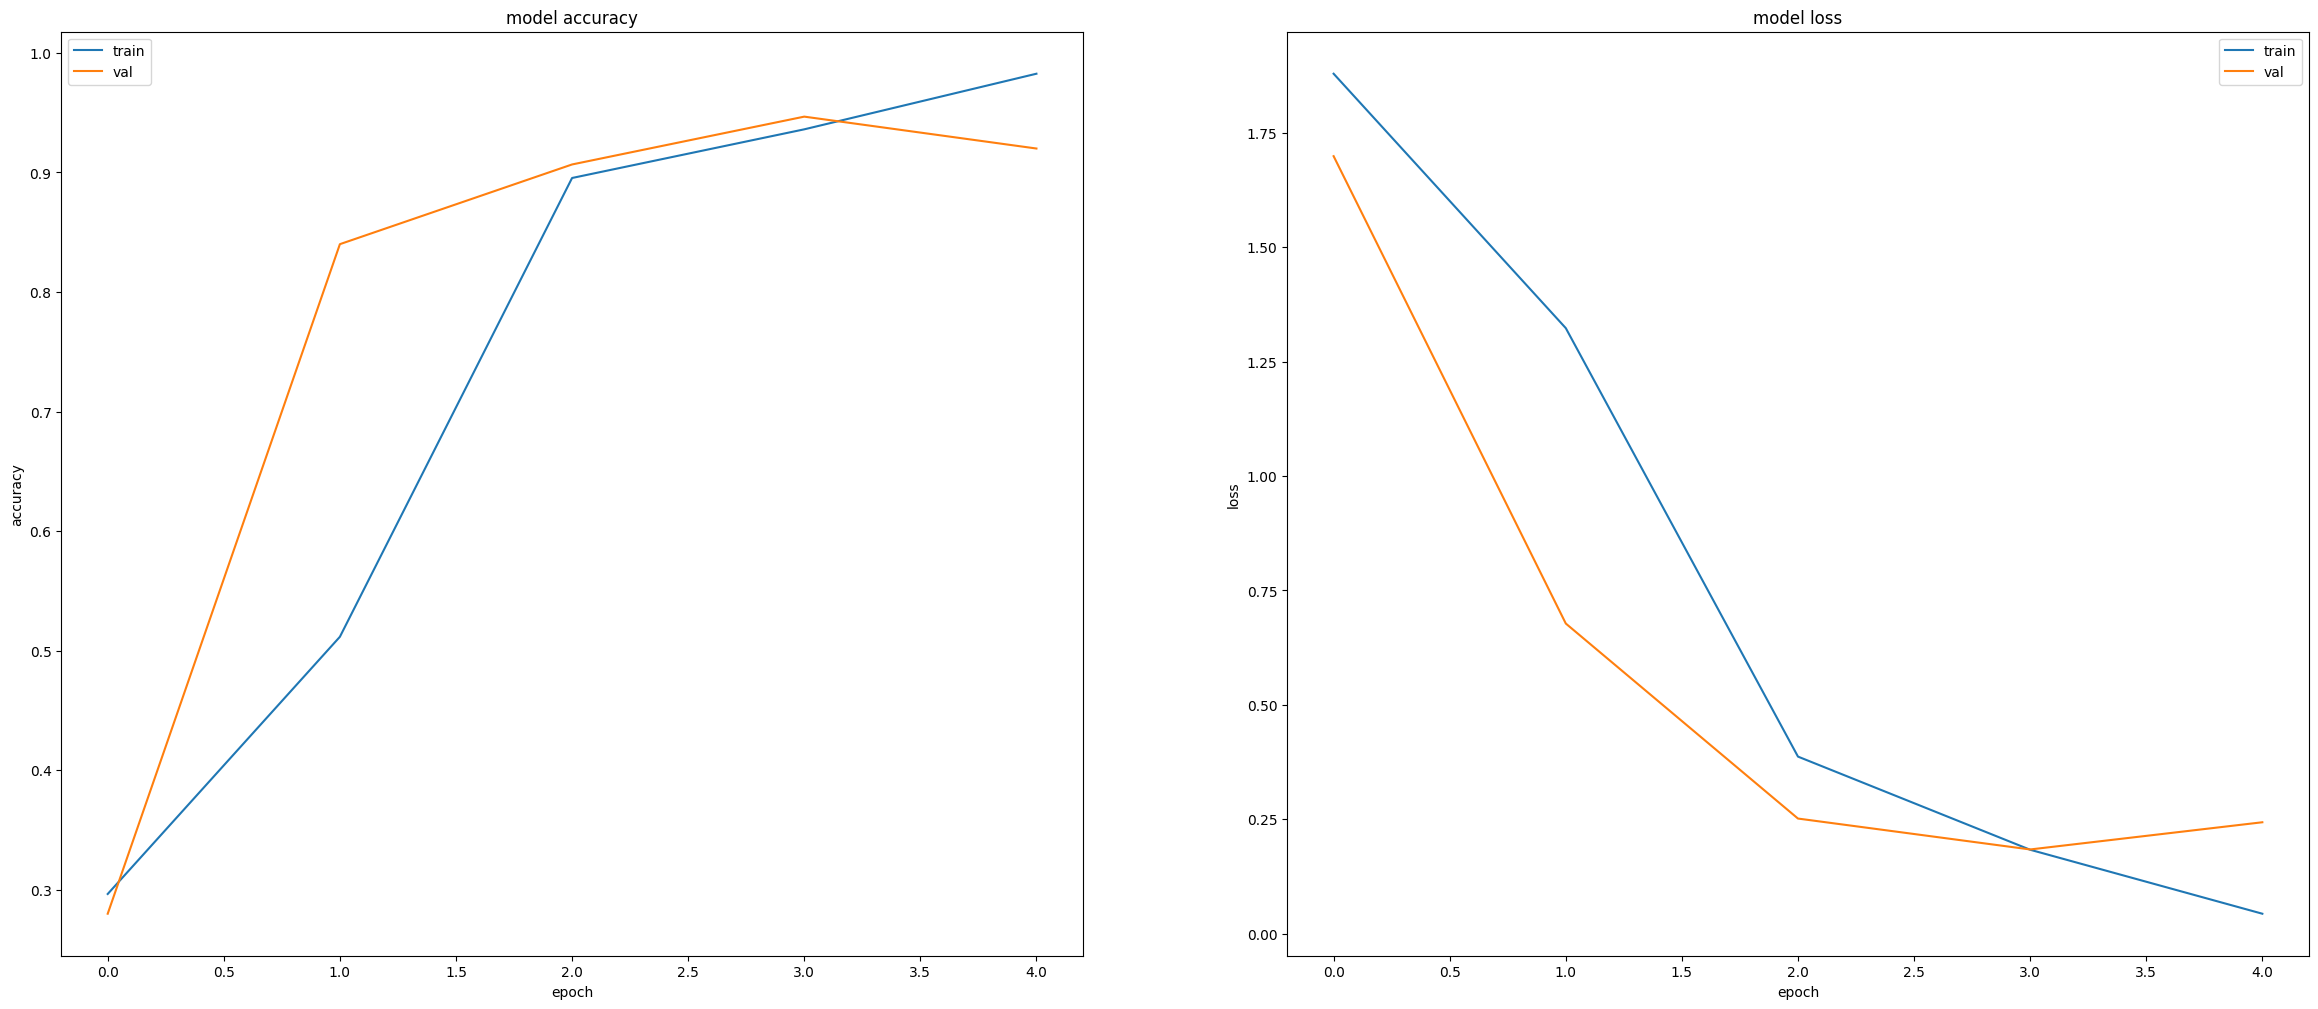

In [ ]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step
Accuracy: 0.9622641509433962
Recal: 0.9588293650793651
F1: 0.9603216228216228
Precision: 0.9641884531590414


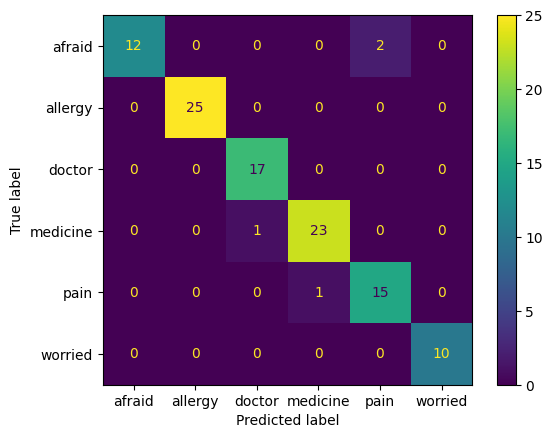

In [ ]:
history_vgg.model.load_weights('best_model_vgg.h5')

predictionsvgg=history_vgg.model.predict(x_test)

y_pred_classes = np.argmax(predictionsvgg, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm4 = confusion_matrix(y_true_classes, y_pred_classes)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=classes)
disp4.plot()

The results are very good, from the confusion matrix we can see that we have 3 false negatives:
- 1 out of 24 for medicine, where it was classified as doctor
- 1 out of 16 for pain, where it was classified as medicine
- 2 out of 14 for afraid, where it was classified as pain

This is backed up by the Accuracy (0.9622641509433962). It is very good that we have similar results for all the evaluation methods.

## 2. ResNet

In [8]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [20]:
resNet=ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
resNet.trainable = False
model_res = Sequential()
model_res.add(resNet)

model_res.add(Flatten())
model_res.add(Dense(512, activation='relu'))
model_res.add(Dropout(0.5))

model_res.add(Dense(len(classes), activation='softmax'))


learning_rate = 0.0001
batch_size = 64
epochs = 120

adam = Adam(learning_rate=learning_rate)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
save_model_res = ModelCheckpoint('best_model_res.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=2)
model_res.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
history_res = model_res.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle = True, verbose=1, validation_data=(x_val, y_val), callbacks=[save_model_res, early_stop])

Epoch 1/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1149 - loss: 3.9189   
Epoch 1: val_loss improved from None to 4.09746, saving model to best_model_res.h5



Epoch 1: finished saving model to best_model_res.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 14s/step - accuracy: 0.1337 - loss: 4.0909 - val_accuracy: 0.2267 - val_loss: 4.0975
Epoch 2/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.2416 - loss: 4.3479
Epoch 2: val_loss improved from 4.09746 to 2.82446, saving model to best_model_res.h5



Epoch 2: finished saving model to best_model_res.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 10s/step - accuracy: 0.2326 - loss: 4.0942 - val_accuracy: 0.1467 - val_loss: 2.8245
Epoch 3/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.1962 - loss: 2.6209
Epoch 3: val_loss improved from 2.82446 to 1.75053, saving model to best_model_res.h5



Epoch 3: finished saving model to best_model_res.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 8s/step - accuracy: 0.1744 - loss: 2.5579 - val_accuracy: 0.3067 - val_loss: 1.7505
Epoch 4/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.1389 - loss: 2.1885
Epoch 4: val_loss did not improve from 1.75053
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - accuracy: 0.1512 - loss: 2.2632 - val_accuracy: 0.1733 - val_loss: 1.8092
Epoch 5/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.2559 - loss: 1.9643
Epoch 5: val_loss did not improve from 1.75053
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.2442 - loss: 1.9100 - val_accuracy: 0.2267 - val_loss: 1.7814
Epoch 6/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.2825 - loss: 1.9470
Epoch 6: val_loss did not improve from 1.75053
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.2849 - loss: 1.9402 - val_accuracy: 0.3333 - val_loss: 1.8018
Epoch 7/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.3117 - loss: 1.7771
Epoch 7:


Epoch 7: finished saving model to best_model_res.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step - accuracy: 0.3023 - loss: 1.7842 - val_accuracy: 0.2533 - val_loss: 1.6721
Epoch 8/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.3026 - loss: 1.6622
Epoch 8: val_loss improved from 1.67208 to 1.60718, saving model to best_model_res.h5


...


Epoch 107: finished saving model to best_model_res.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 10s/step - accuracy: 0.8547 - loss: 0.5664 - val_accuracy: 0.6800 - val_loss: 0.9145
Epoch 108/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7941 - loss: 0.6106
Epoch 108: val_loss improved from 0.91452 to 0.89713, saving model to best_model_res.h5



Epoch 108: finished saving model to best_model_res.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 45s 22s/step - accuracy: 0.7965 - loss: 0.6129 - val_accuracy: 0.6667 - val_loss: 0.8971
Epoch 109/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8695 - loss: 0.5509
Epoch 109: val_loss did not improve from 0.89713
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.8663 - loss: 0.5601 - val_accuracy: 0.6133 - val_loss: 0.9091
Epoch 110/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8448 - loss: 0.5524
Epoch 110: val_loss did not improve from 0.89713
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 337ms/step - accuracy: 0.8547 - loss: 0.5384 - val_accuracy: 0.6267 - val_loss: 0.9208
Epoch 111/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8806 - loss: 0.4881
Epoch 111: val_loss did not improve from 0.89713
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step - accuracy: 0.8605 - loss: 0.5173 - val_accuracy: 0.6400 - val_loss: 0.9050
Epoch 112/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8714 - loss


Epoch 112: finished saving model to best_model_res.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 13s/step - accuracy: 0.8721 - loss: 0.5447 - val_accuracy: 0.6933 - val_loss: 0.8878
Epoch 113/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8325 - loss: 0.5699
Epoch 113: val_loss did not improve from 0.88782
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accuracy: 0.8256 - loss: 0.5565 - val_accuracy: 0.6400 - val_loss: 0.8978
Epoch 114/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8454 - loss: 0.5834
Epoch 114: val_loss did not improve from 0.88782
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.8488 - loss: 0.5657 - val_accuracy: 0.6533 - val_loss: 0.9148
Epoch 115/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8435 - loss: 0.5175
Epoch 115: val_loss did not improve from 0.88782
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step - accuracy: 0.8430 - loss: 0.5211 - val_accuracy: 0.6667 - val_loss: 0.8965
Epoch 116/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.8857 - loss


Epoch 116: finished saving model to best_model_res.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 17s/step - accuracy: 0.8837 - loss: 0.5262 - val_accuracy: 0.6800 - val_loss: 0.8855
Epoch 117/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8441 - loss: 0.5805
Epoch 117: val_loss did not improve from 0.88545
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - accuracy: 0.8605 - loss: 0.5362 - val_accuracy: 0.6667 - val_loss: 0.8921
Epoch 118/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8350 - loss: 0.5448
Epoch 118: val_loss improved from 0.88545 to 0.88491, saving model to best_model_res.h5



Epoch 118: finished saving model to best_model_res.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 14s/step - accuracy: 0.8488 - loss: 0.5224 - val_accuracy: 0.6533 - val_loss: 0.8849
Epoch 119/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8754 - loss: 0.5016
Epoch 119: val_loss did not improve from 0.88491
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step - accuracy: 0.8605 - loss: 0.5270 - val_accuracy: 0.7067 - val_loss: 0.8862
Epoch 120/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9053 - loss: 0.5106
Epoch 120: val_loss did not improve from 0.88491
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step - accuracy: 0.8721 - loss: 0.5533 - val_accuracy: 0.6533 - val_loss: 0.8850


4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step
Accuracy: 0.8113207547169812
Recal: 0.7889192343604109
F1: 0.7916943432062814
Precision: 0.8332848324514991


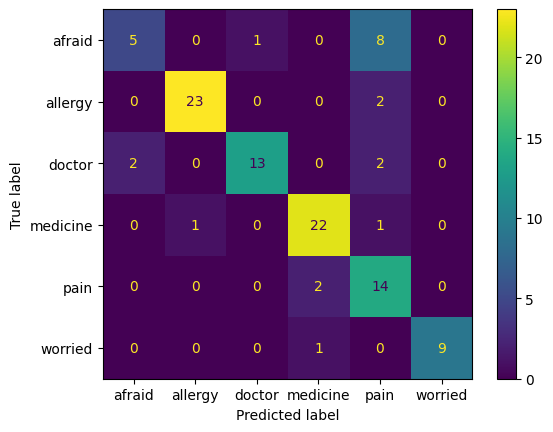

In [21]:
history_res.model.load_weights('best_model_res.h5')

predictionsres=history_res.model.predict(x_test)

y_pred_classes = np.argmax(predictionsres, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm5 = confusion_matrix(y_true_classes, y_pred_classes)
disp5 = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=classes)
disp5.plot()